In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)

In [13]:
RAW_PATH = '../data/raw/loan.csv'
RAW_SAMPLE_SIZE = 50_000

df_raw = pd.read_csv(RAW_PATH, nrows=RAW_SAMPLE_SIZE, low_memory=False)

print('Raw Data Sample Profile')
print(f'Sample rows  : {len(df_raw):,}')
print(f'Total columns: {df_raw.shape[1]:,}')
display(df_raw.head())

print('Note: this is the first 50,000 rows for fast raw-data diagnostics, not a random sample.')

Raw Data Sample Profile
Sample rows  : 50,000
Total columns: 145


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


Note: this is the first 50,000 rows for fast raw-data diagnostics, not a random sample.


## 1. Missingness Assessment

Missingness is evaluated on the raw-data diagnostic sample to identify fields requiring review. A high missingness rate does not automatically justify dropping a feature: availability timing, business meaning, and whether missingness carries risk signal must also be assessed before modelling.

Features with missing values: 61
Features above 50% missing : 43


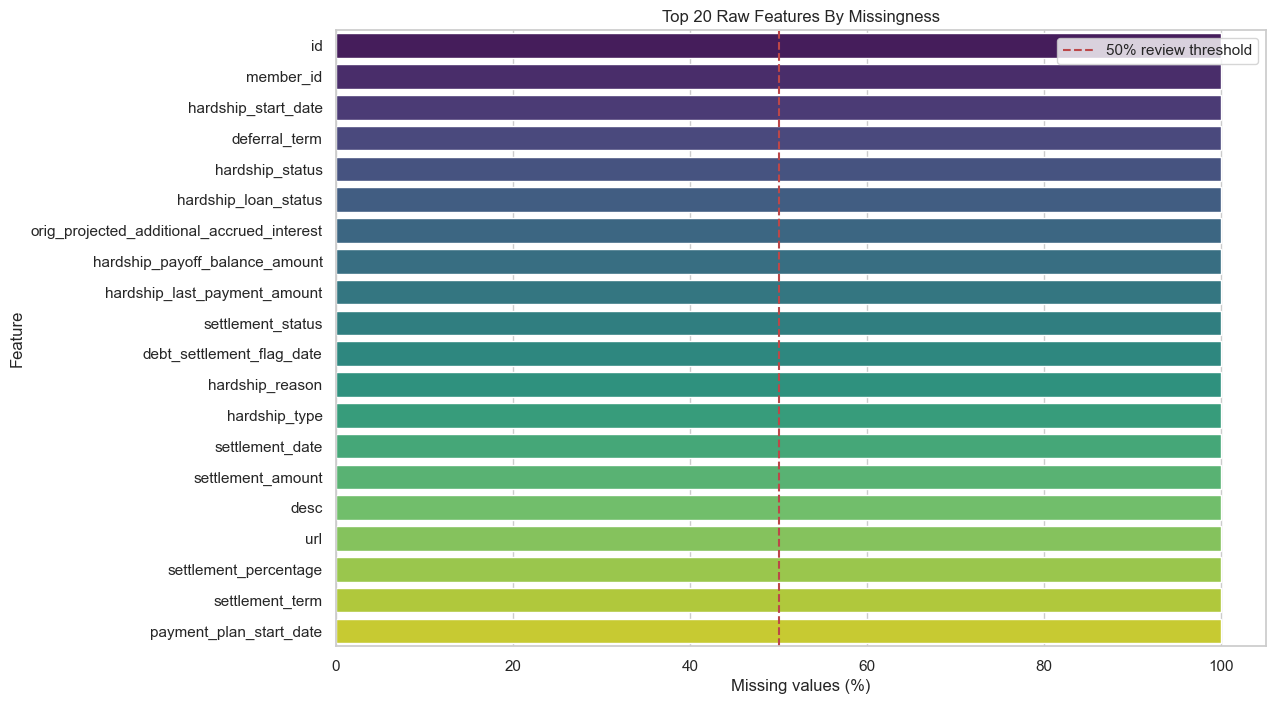

,missing_pct
id,100.0
member_id,100.0
hardship_start_date,100.0
deferral_term,100.0
hardship_status,100.0
hardship_loan_status,100.0
orig_projected_additional_accrued_interest,100.0
hardship_payoff_balance_amount,100.0
hardship_last_payment_amount,100.0
settlement_status,100.0


In [3]:
missing_pct = (df_raw.isna().mean() * 100).sort_values(ascending=False)
missing_features = missing_pct[missing_pct > 0]
high_missing_features = missing_features[missing_features > 50]

print(f'Features with missing values: {len(missing_features):,}')
print(f'Features above 50% missing : {len(high_missing_features):,}')

missing_plot = missing_features.head(20).rename_axis('feature').reset_index(name='missing_pct')
plt.figure(figsize=(12, 8))
sns.barplot(data=missing_plot, x='missing_pct', y='feature', hue='feature', legend=False, palette='viridis')
plt.axvline(50, color='#bc4749', linestyle='--', label='50% review threshold')
plt.title('Top 20 Raw Features By Missingness')
plt.xlabel('Missing values (%)')
plt.ylabel('Feature')
plt.legend()
plt.show()

display(missing_features.rename('missing_pct').to_frame().head(20))

## 2. Raw Outcome Status And Cohort Definition

`loan_status` contains both resolved and unresolved loans. The final modelling cohort uses `Fully Paid` as good loans and `Charged Off` or `Default` as bad loans. Current and other unresolved statuses are excluded because their final repayment outcome is unknown.

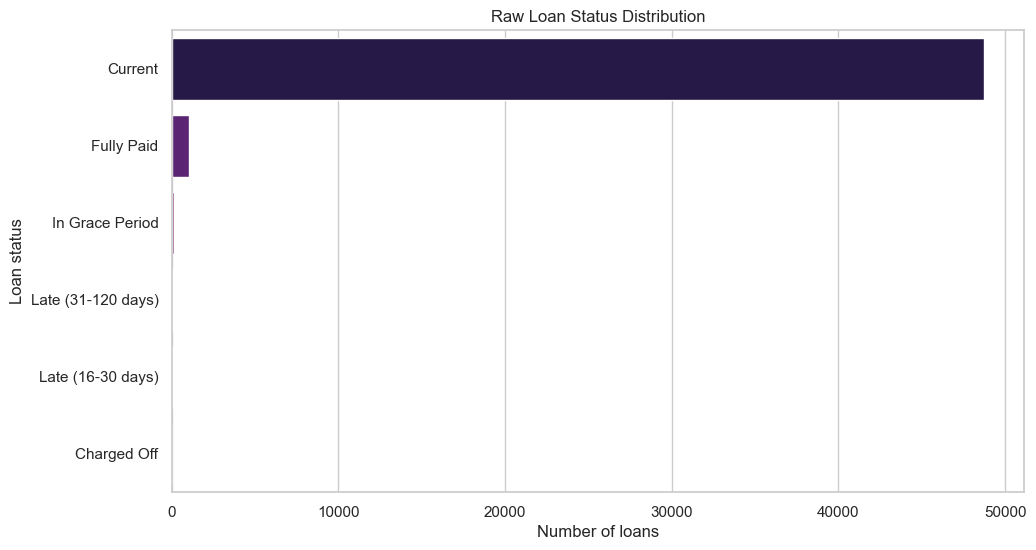

,Raw status,Cohort decision,Treatment
0,Fully Paid,Good,Included as target 0
1,Charged Off,Bad,Included as target 1
2,Default,Bad,Included as target 1
3,Current and other statuses,Unresolved,Excluded from final cohort


In [4]:
status_counts = df_raw['loan_status'].value_counts(dropna=False)
status_plot = status_counts.rename_axis('loan_status').reset_index(name='loan_count')

plt.figure(figsize=(11, 6))
sns.barplot(data=status_plot, x='loan_count', y='loan_status', hue='loan_status', legend=False, palette='magma')
plt.title('Raw Loan Status Distribution')
plt.xlabel('Number of loans')
plt.ylabel('Loan status')
plt.show()

status_mapping = pd.DataFrame([
    ('Fully Paid', 'Good', 'Included as target 0'),
    ('Charged Off', 'Bad', 'Included as target 1'),
    ('Default', 'Bad', 'Included as target 1'),
    ('Current and other statuses', 'Unresolved', 'Excluded from final cohort'),
], columns=['Raw status', 'Cohort decision', 'Treatment'])
display(status_mapping)

## 3. Raw Numeric Distributions

The distributions of requested loan amount and assigned interest rate provide an initial view of portfolio composition. The later sections evaluate their relationship with observed default on the final processed cohort.

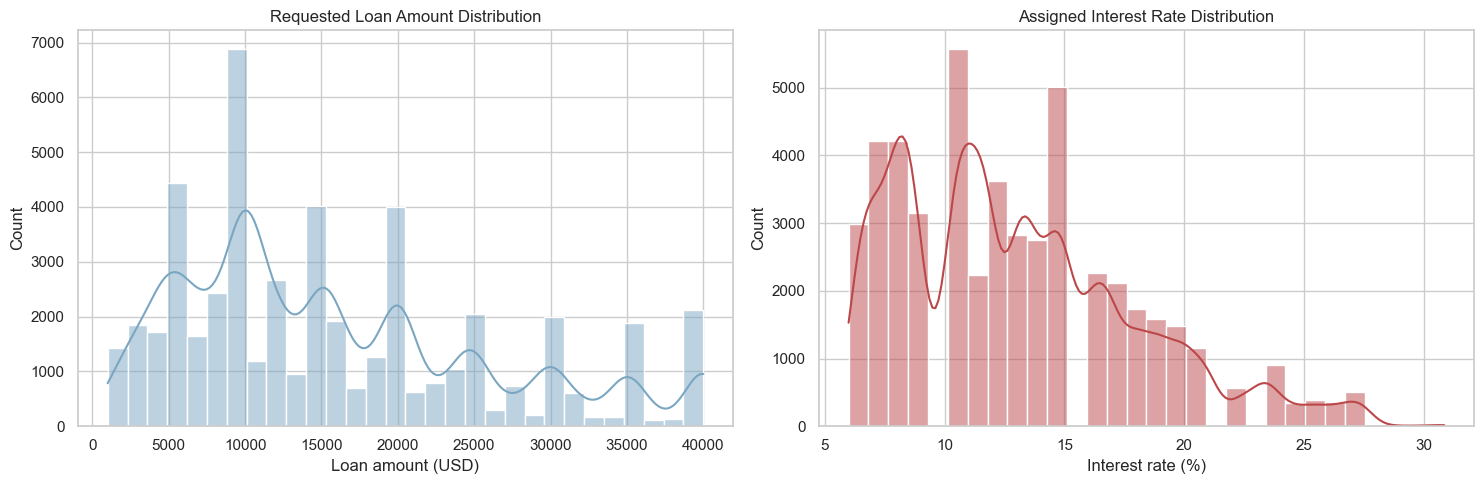

In [5]:
interest_rate = pd.to_numeric(
    df_raw['int_rate'].astype(str).str.replace('%', '', regex=False).str.strip(),
    errors='coerce',
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data=df_raw, x='loan_amnt', bins=30, kde=True, color='#7aa6c2', ax=axes[0])
axes[0].set_title('Requested Loan Amount Distribution')
axes[0].set_xlabel('Loan amount (USD)')

sns.histplot(interest_rate, bins=30, kde=True, color='#bc4749', ax=axes[1])
axes[1].set_title('Assigned Interest Rate Distribution')
axes[1].set_xlabel('Interest rate (%)')

plt.tight_layout()
plt.show()

## 4. Leakage Illustration

Post-origination repayment fields can almost reveal the target outcome and must not be used for underwriting. This illustration intentionally compares approved application fields with known leakage fields to make the exclusion rationale explicit.

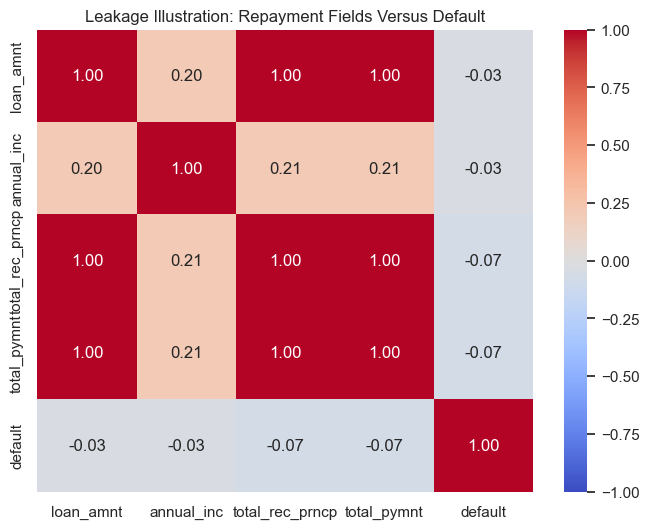

Decision: total_rec_prncp and total_pymnt are excluded because they are only known after origination.


In [6]:
resolved_statuses = ['Fully Paid', 'Charged Off', 'Default']
df_leakage = df_raw[df_raw['loan_status'].isin(resolved_statuses)].copy()
df_leakage['default'] = np.where(df_leakage['loan_status'] == 'Fully Paid', 0, 1)

leakage_features = ['loan_amnt', 'annual_inc', 'total_rec_prncp', 'total_pymnt', 'default']
leakage_correlation = df_leakage[leakage_features].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(leakage_correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f', vmin=-1, vmax=1)
plt.title('Leakage Illustration: Repayment Fields Versus Default')
plt.show()

print('Decision: total_rec_prncp and total_pymnt are excluded because they are only known after origination.')

## 5. Modelling Cohort And Current Processed Data

The preceding raw-data diagnostics use the first 50,000 rows for speed. This section uses the full ETL output for representative risk analysis. The final cohort contains only resolved outcomes: `Fully Paid` is good and `Charged Off`/`Default` are bad.

> Limitation: the current processed dataset does not retain `issue_d`. Therefore, this EDA cannot yet test default stability by application vintage. An out-of-time analysis will be added after `issue_d` is retained solely for splitting.

--- PROFIL MODELLING COHORT ---
Jumlah observasi : 1,303,638
Jumlah predictor : 10
Good loans (0)  : 1,041,952
Bad loans (1)   : 261,686
Default rate   : 20.07%


Duplicate rows : 0


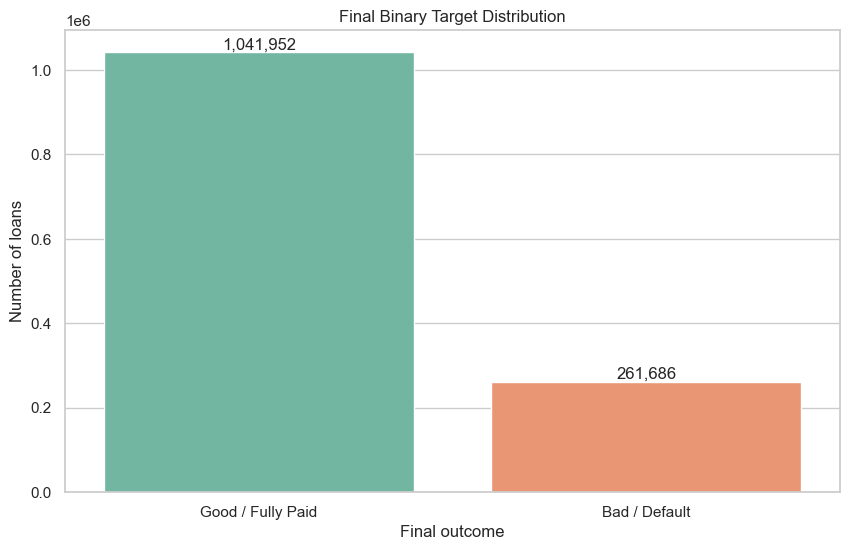

In [7]:
PROCESSED_PATH = "../data/processed/credit_applications_cleaned.csv"
df = pd.read_csv(PROCESSED_PATH)

print("--- PROFIL MODELLING COHORT ---")
print(f"Jumlah observasi : {len(df):,}")
print(f"Jumlah predictor : {df.shape[1] - 1}")
print(f"Good loans (0)  : {(df['default'] == 0).sum():,}")
print(f"Bad loans (1)   : {(df['default'] == 1).sum():,}")
print(f"Default rate   : {df['default'].mean():.2%}")
print(f"Duplicate rows : {df.duplicated().sum():,}")

target_counts = df['default'].map({0: 'Good / Fully Paid', 1: 'Bad / Default'}).value_counts()
ax = sns.barplot(x=target_counts.index, y=target_counts.values, hue=target_counts.index, legend=False, palette='Set2')
ax.set_title('Final Binary Target Distribution')
ax.set_xlabel('Final outcome')
ax.set_ylabel('Number of loans')
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')
plt.show()

## 6. Data Quality And Feature Contract

The model must only consume information available at application or origination. The table below records the current feature contract. Repayment, recovery, collection, and settlement fields are excluded because they become known after the loan is issued.

`int_rate` is conditional: it is valid only when scoring occurs after Lending Club pricing/underwriting is available. If the intended model sets pricing, `int_rate` must be excluded.

In [8]:
feature_contract = pd.DataFrame([
    ('loan_amnt', 'Requested loan amount', 'Application', 'Allowed'),
    ('int_rate', 'Assigned interest rate', 'Underwriting / pricing', 'Conditional'),
    ('annual_inc', 'Self-reported annual income', 'Application', 'Allowed'),
    ('dti', 'Debt-to-income ratio', 'Application', 'Allowed'),
    ('revol_util', 'Revolving credit utilization', 'Credit bureau', 'Allowed'),
    ('delinq_2yrs', 'Delinquencies in prior 2 years', 'Credit bureau', 'Allowed'),
    ('inq_last_6mths', 'Credit inquiries in prior 6 months', 'Credit bureau', 'Allowed'),
    ('emp_length_years', 'Employment duration', 'Application', 'Allowed'),
    ('home_ownership', 'Housing status', 'Application', 'Allowed'),
    ('loan_purpose', 'Declared loan purpose', 'Application', 'Allowed'),
], columns=['Feature', 'Business meaning', 'Availability', 'Decision'])

display(feature_contract)

quality = pd.DataFrame({
    'dtype': df.drop(columns='default').dtypes.astype(str),
    'missing_pct': (df.drop(columns='default').isna().mean() * 100).round(2),
    'unique_values': df.drop(columns='default').nunique(),
}).sort_values(['missing_pct', 'unique_values'], ascending=[False, False])
display(quality)

print('Examples of excluded post-origination fields: total_pymnt, total_rec_prncp, recoveries, out_prncp, last_pymnt_d.')

,Feature,Business meaning,Availability,Decision
0,loan_amnt,Requested loan amount,Application,Allowed
1,int_rate,Assigned interest rate,Underwriting / pricing,Conditional
2,annual_inc,Self-reported annual income,Application,Allowed
3,dti,Debt-to-income ratio,Application,Allowed
4,revol_util,Revolving credit utilization,Credit bureau,Allowed
5,delinq_2yrs,Delinquencies in prior 2 years,Credit bureau,Allowed
6,inq_last_6mths,Credit inquiries in prior 6 months,Credit bureau,Allowed
7,emp_length_years,Employment duration,Application,Allowed
8,home_ownership,Housing status,Application,Allowed
9,loan_purpose,Declared loan purpose,Application,Allowed


,dtype,missing_pct,unique_values
annual_inc,float64,0.0,62989
dti,float64,0.0,6870
loan_amnt,int64,0.0,1553
revol_util,float64,0.0,1363
int_rate,float64,0.0,654
delinq_2yrs,float64,0.0,30
loan_purpose,object,0.0,14
emp_length_years,float64,0.0,11
inq_last_6mths,float64,0.0,9
home_ownership,object,0.0,6


Examples of excluded post-origination fields: total_pymnt, total_rec_prncp, recoveries, out_prncp, last_pymnt_d.


## 7. Numeric Feature Profile And Plausibility Checks

This section checks distribution, missingness, and potentially implausible values for the features currently available to the model. Extreme values are reported rather than automatically removed: the final treatment must be fit on training data only.

,count,mean,std,min,1%,25%,50%,75%,99%,max,missing_pct
loan_amnt,1303638.0,14416.84,8699.57,500.00,1500.00,8000.00,12000.00,20000.00,35000.00,40000.00,0.0
int_rate,1303638.0,13.26,4.76,5.31,5.32,9.75,12.74,15.99,26.30,30.99,0.0
annual_inc,1303638.0,76158.75,70048.27,0.00,18000.00,45840.00,65000.00,90000.00,250000.00,10999200.00,0.0
dti,1303638.0,18.26,10.94,-1.00,1.79,11.79,17.61,24.04,38.37,999.00,0.0
delinq_2yrs,1303638.0,0.32,0.88,0.00,0.00,0.00,0.00,0.00,4.00,39.00,0.0
inq_last_6mths,1303638.0,0.66,0.94,0.00,0.00,0.00,0.00,1.00,4.00,8.00,0.0
revol_util,1303638.0,51.91,24.49,0.00,1.10,33.60,52.30,70.80,98.20,892.30,0.0
emp_length_years,1303638.0,5.70,3.73,0.00,0.00,2.00,6.00,10.00,10.00,10.00,0.0


,count
annual_inc <= 0,302
dti < 0,2
revol_util outside 0-100,4537
loan_amnt <= 0,0


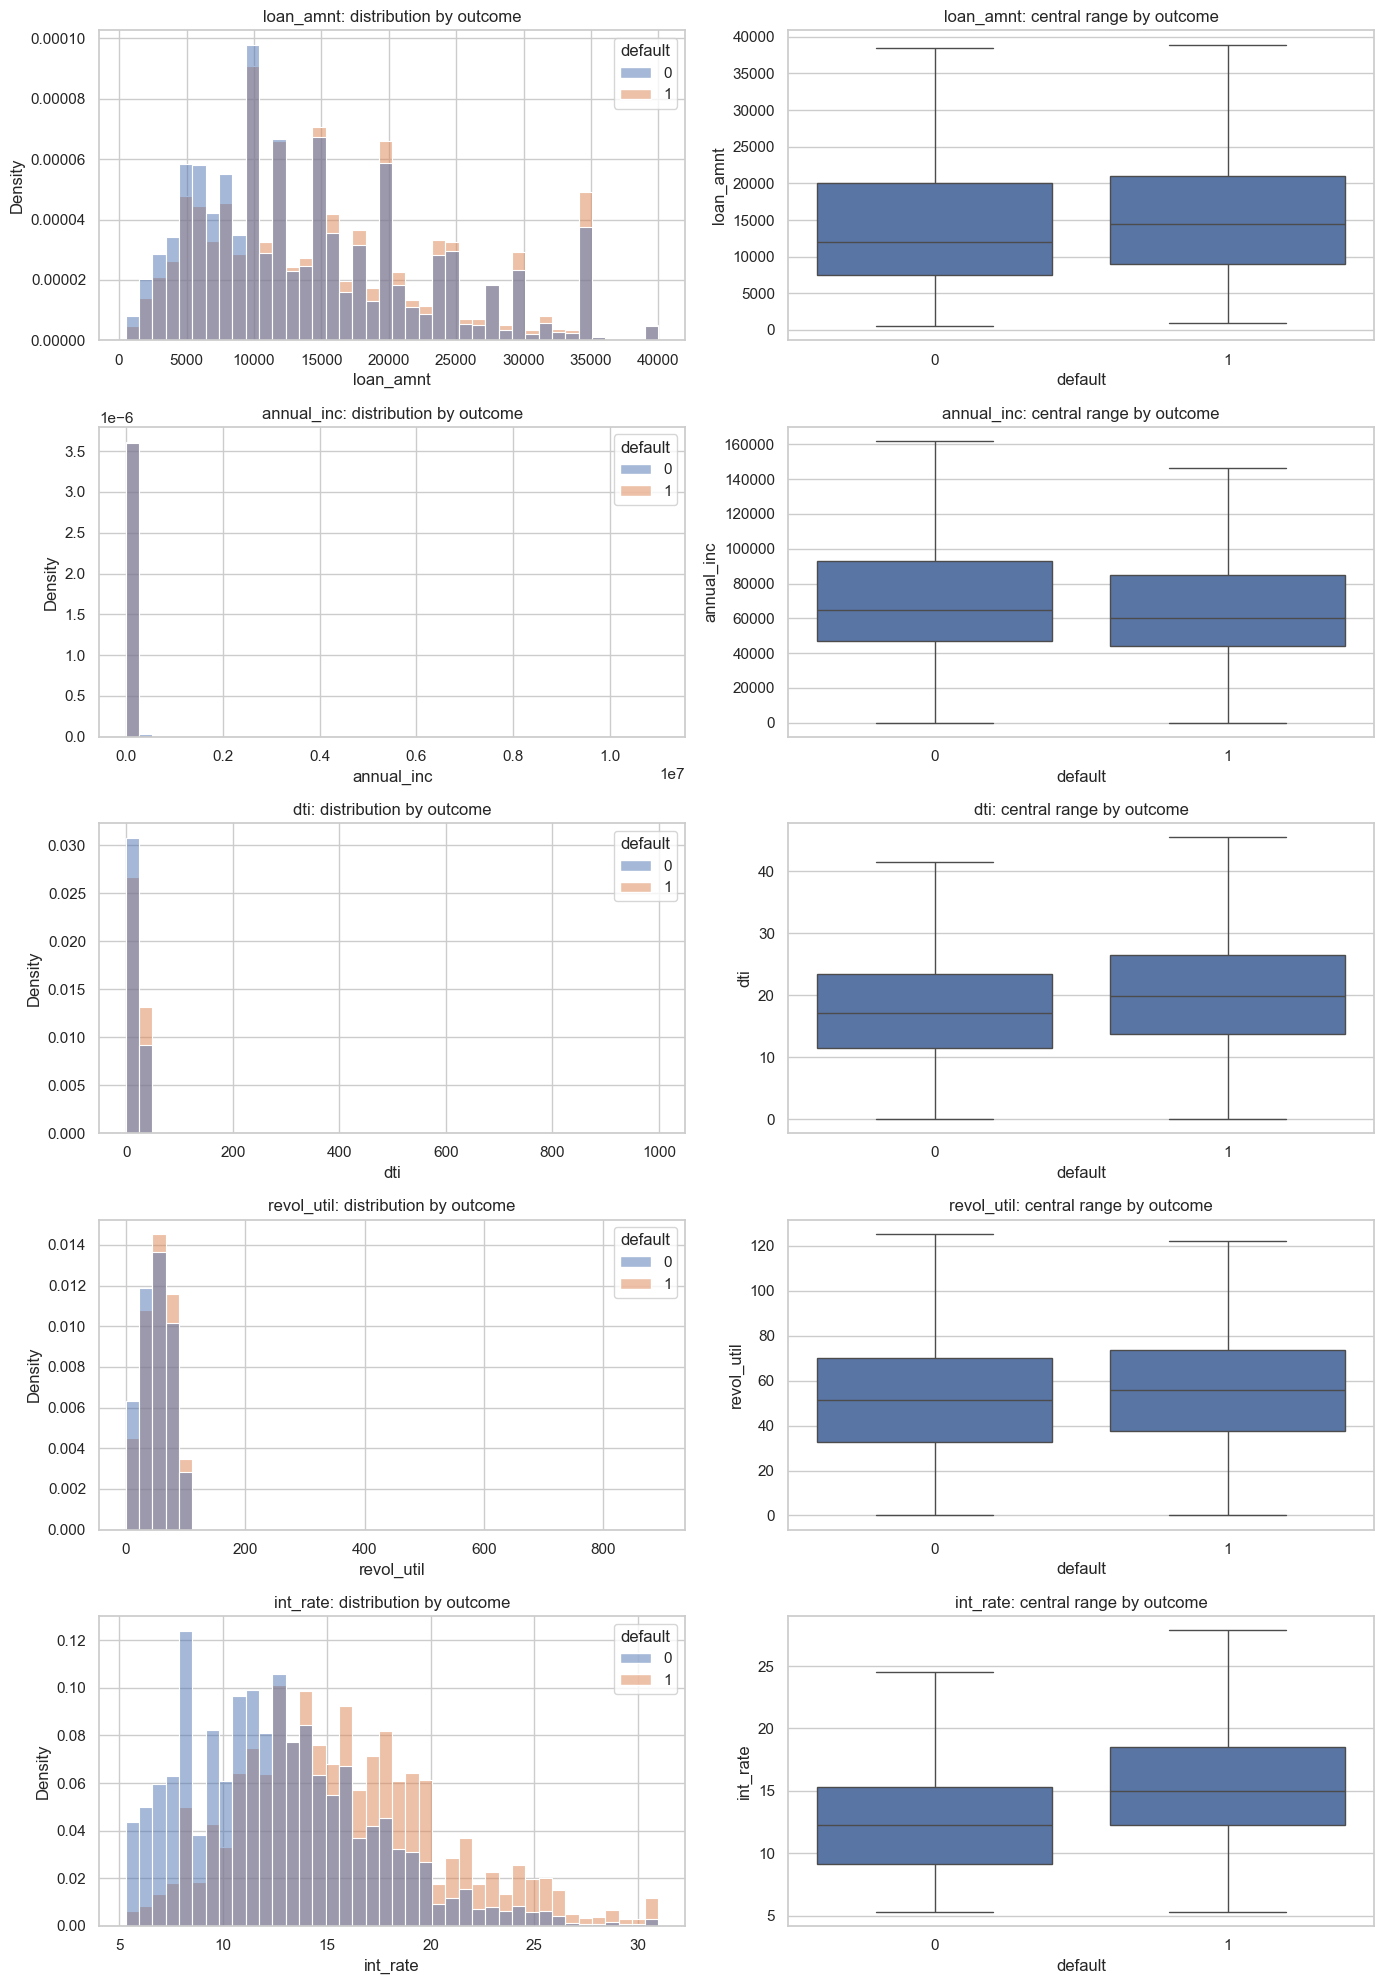

In [9]:
numeric_features = df.drop(columns='default').select_dtypes(include=np.number).columns.tolist()
numeric_summary = df[numeric_features].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
numeric_summary['missing_pct'] = (df[numeric_features].isna().mean() * 100).round(2)
display(numeric_summary.round(2))

checks = pd.Series({
    'annual_inc <= 0': (df['annual_inc'] <= 0).sum(),
    'dti < 0': (df['dti'] < 0).sum(),
    'revol_util outside 0-100': ((df['revol_util'] < 0) | (df['revol_util'] > 100)).sum(),
    'loan_amnt <= 0': (df['loan_amnt'] <= 0).sum(),
})
display(checks.to_frame('count'))

plot_features = [feature for feature in ['loan_amnt', 'annual_inc', 'dti', 'revol_util', 'int_rate'] if feature in df]
fig, axes = plt.subplots(len(plot_features), 2, figsize=(14, 4 * len(plot_features)))
for row, feature in enumerate(plot_features):
    sns.histplot(data=df, x=feature, hue='default', bins=40, stat='density', common_norm=False, ax=axes[row, 0])
    axes[row, 0].set_title(f'{feature}: distribution by outcome')
    sns.boxplot(data=df.sample(min(len(df), 100_000), random_state=42), x='default', y=feature, ax=axes[row, 1], showfliers=False)
    axes[row, 1].set_title(f'{feature}: central range by outcome')
plt.tight_layout()
plt.show()

## 8. Default Rate By Feature Bands

Overall distributions do not show whether a feature separates risk. The following charts use quantile bands for numeric features and show both loan volume and observed default rate. They are descriptive only; bins for future modelling must be learned from training data, not from the final test set.

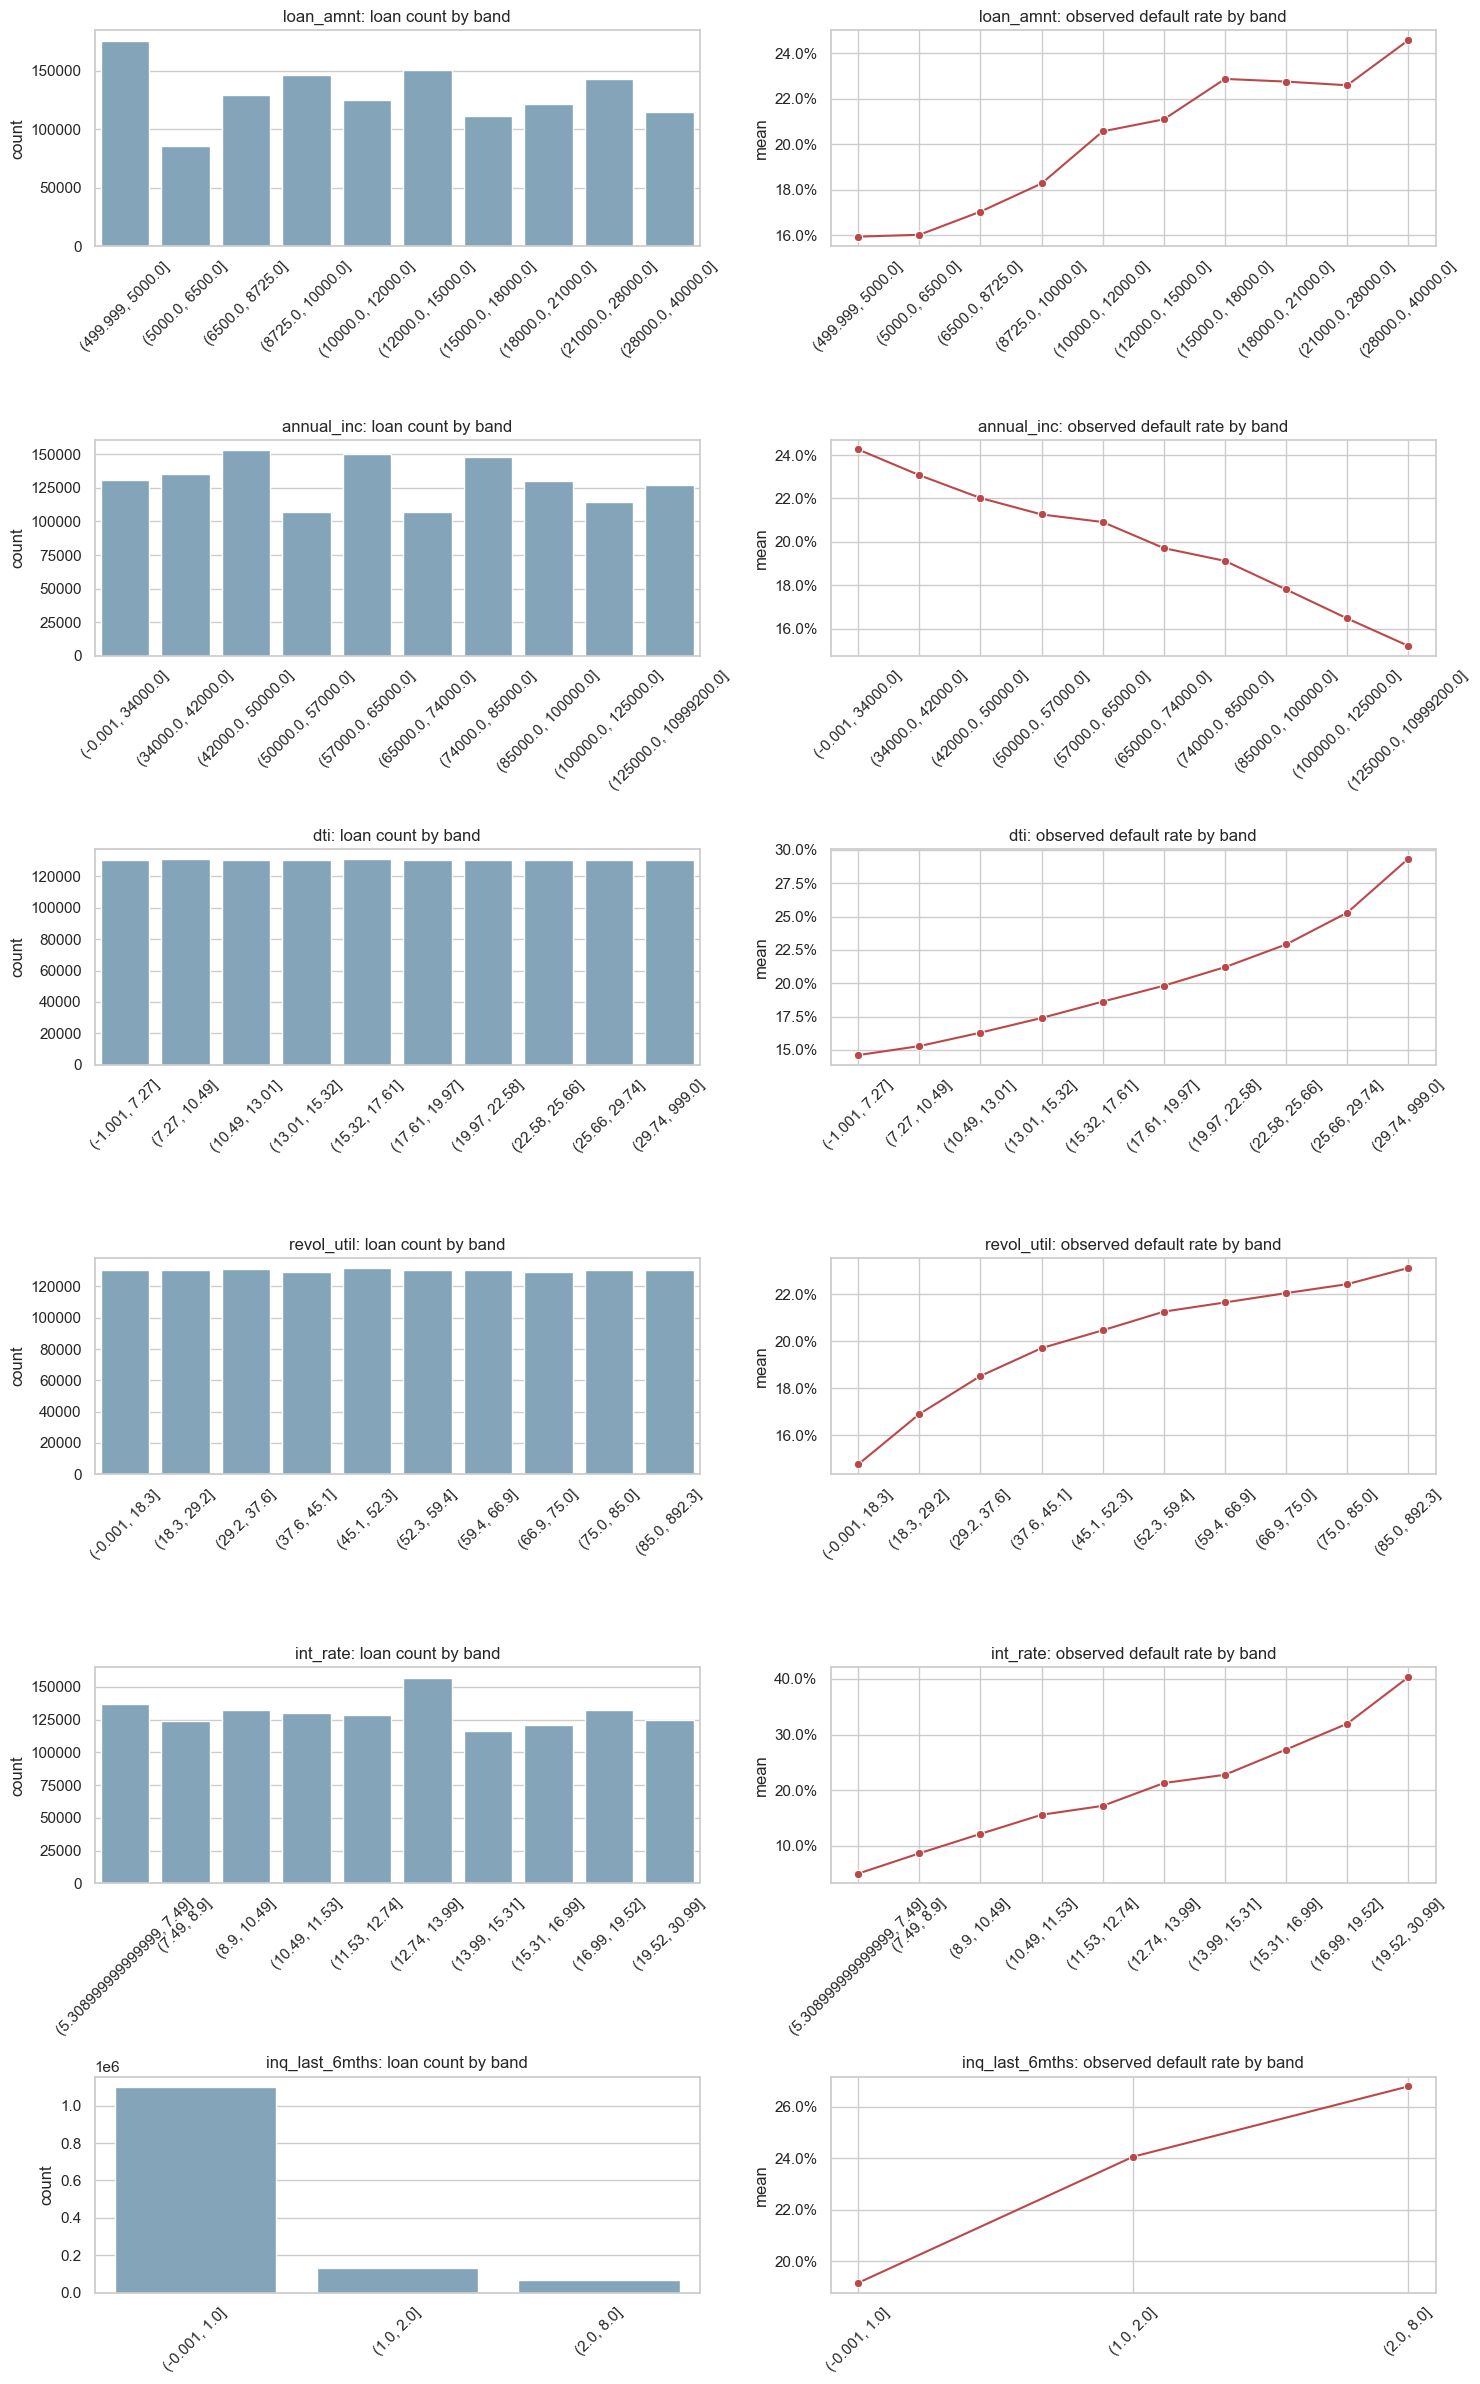

In [10]:
def default_rate_by_band(data, feature, bands=10):
    analysis = data[[feature, 'default']].dropna().copy()
    analysis['band'] = pd.qcut(analysis[feature], q=bands, duplicates='drop')
    result = analysis.groupby('band', observed=False)['default'].agg(['count', 'mean']).reset_index()
    result['band'] = result['band'].astype(str)
    return result

rate_features = [feature for feature in ['loan_amnt', 'annual_inc', 'dti', 'revol_util', 'int_rate', 'inq_last_6mths'] if feature in df]
fig, axes = plt.subplots(len(rate_features), 2, figsize=(15, 4 * len(rate_features)))
for row, feature in enumerate(rate_features):
    rates = default_rate_by_band(df, feature)
    sns.barplot(data=rates, x='band', y='count', color='#7aa6c2', ax=axes[row, 0])
    axes[row, 0].set_title(f'{feature}: loan count by band')
    axes[row, 0].tick_params(axis='x', rotation=45)
    axes[row, 0].set_xlabel('')
    sns.lineplot(data=rates, x='band', y='mean', marker='o', color='#bc4749', ax=axes[row, 1])
    axes[row, 1].yaxis.set_major_formatter('{x:.1%}')
    axes[row, 1].set_title(f'{feature}: observed default rate by band')
    axes[row, 1].tick_params(axis='x', rotation=45)
    axes[row, 1].set_xlabel('')
plt.tight_layout()
plt.show()

## 9. Categorical Risk Profile

For categorical application features, volume must be interpreted together with bad rate. Rare categories can show unstable rates, so the table retains the observation count and the chart only displays groups with at least 1,000 loans.

,home_ownership,loan_count,default_rate
0,RENT,517821,0.233496
1,OWN,139849,0.207481
2,ANY,267,0.194757
3,OTHER,144,0.187500
4,MORTGAGE,645509,0.173003
5,NONE,48,0.145833


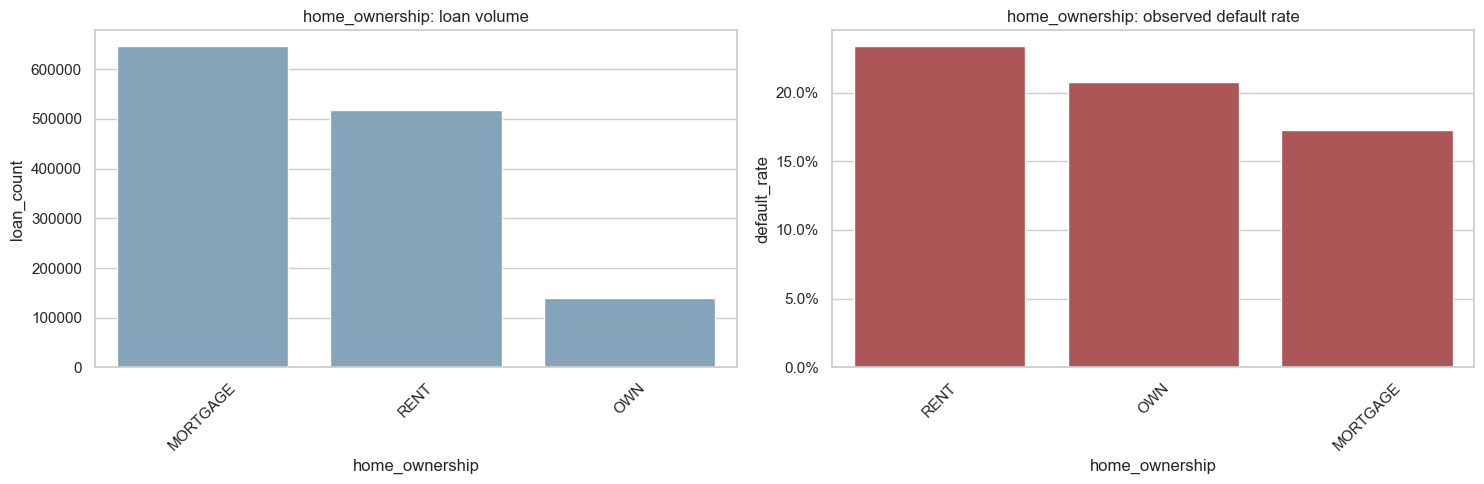

,loan_purpose,loan_count,default_rate
0,small_business,15010,0.297468
1,renewable_energy,911,0.237102
2,moving,9173,0.234493
3,medical,15024,0.219116
4,house,6967,0.217167
5,debt_consolidation,757610,0.212587
6,other,74937,0.211738
7,vacation,8732,0.192396
8,major_purchase,28328,0.187235
9,home_improvement,84497,0.178551


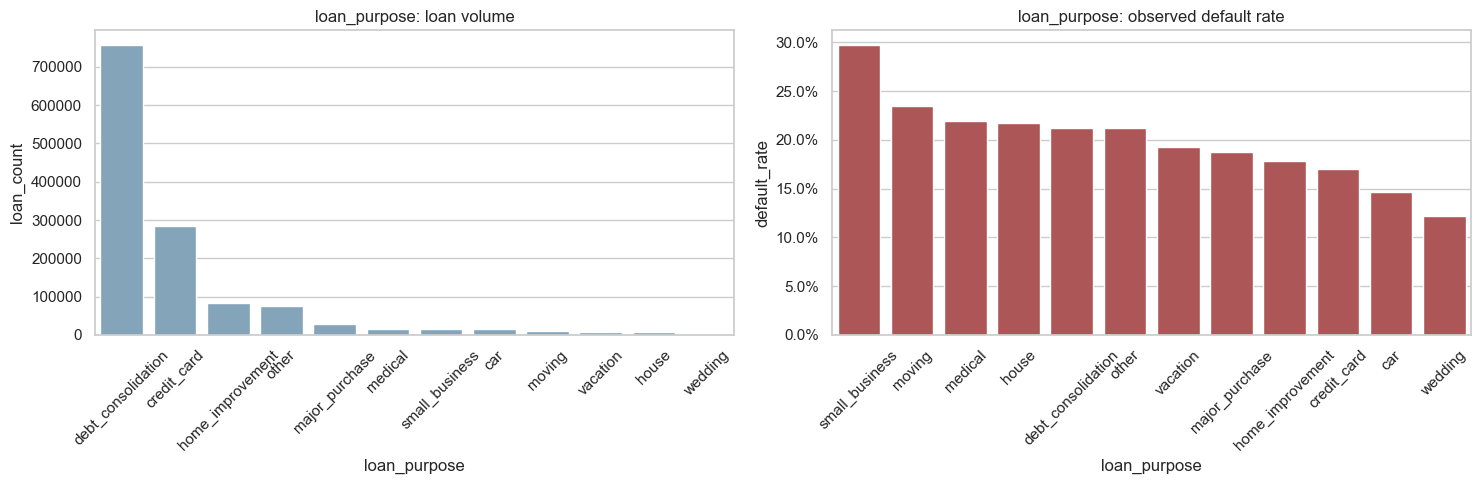

In [11]:
categorical_features = df.drop(columns='default').select_dtypes(include=['object', 'category']).columns.tolist()

for feature in categorical_features:
    profile = (df.groupby(feature, dropna=False)['default']
               .agg(loan_count='size', default_rate='mean')
               .sort_values('default_rate', ascending=False)
               .reset_index())
    display(profile)
    chart_data = profile[profile['loan_count'] >= 1_000].copy()
    if not chart_data.empty:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        sns.barplot(data=chart_data.sort_values('loan_count', ascending=False), x=feature, y='loan_count', color='#7aa6c2', ax=axes[0])
        axes[0].tick_params(axis='x', rotation=45)
        axes[0].set_title(f'{feature}: loan volume')
        sns.barplot(data=chart_data, x=feature, y='default_rate', color='#bc4749', ax=axes[1])
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].yaxis.set_major_formatter('{x:.1%}')
        axes[1].set_title(f'{feature}: observed default rate')
        plt.tight_layout()
        plt.show()

## 10. Relationships, Affordability, And Modelling Implications

The correlation heatmap below intentionally includes only the current pre-origination numeric predictors. It is separate from the earlier leakage illustration, which used post-origination variables solely to demonstrate why they must be excluded.

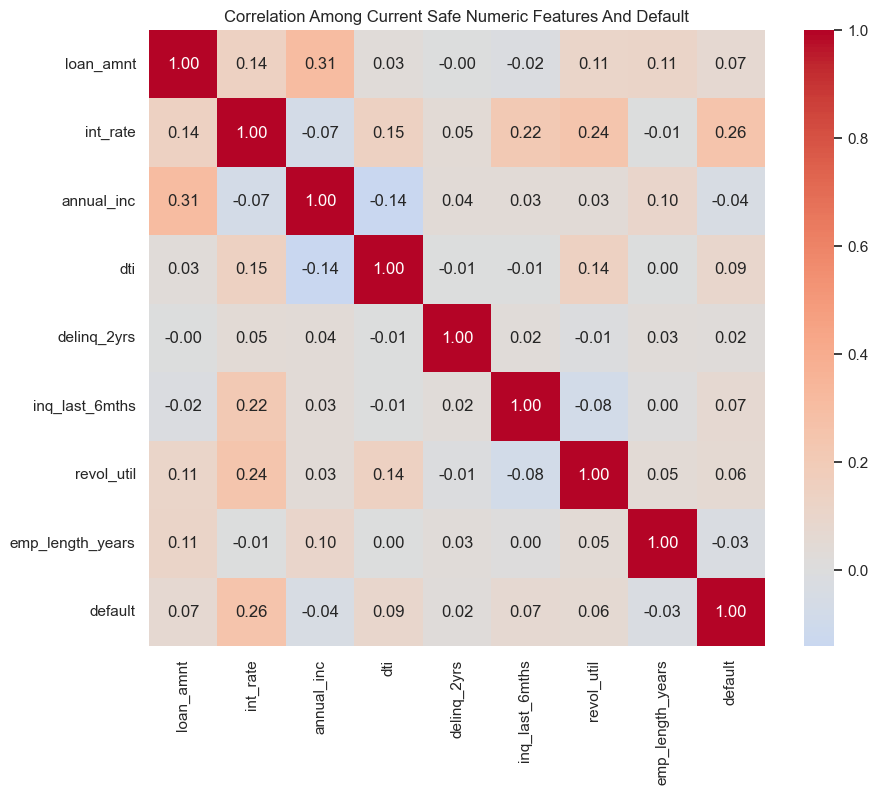

,band,count,default_rate
0,"(-0.000829, 0.075]",132820,0.125960
1,"(0.075, 0.109]",129956,0.144941
2,"(0.109, 0.139]",128597,0.152997
3,"(0.139, 0.167]",131529,0.167058
4,"(0.167, 0.2]",150956,0.181278
5,"(0.2, 0.231]",109786,0.197275
6,"(0.231, 0.268]",129078,0.217279
7,"(0.268, 0.316]",130558,0.242390
8,"(0.316, 0.377]",129739,0.278027
9,"(0.377, 40000.0]",130317,0.304074


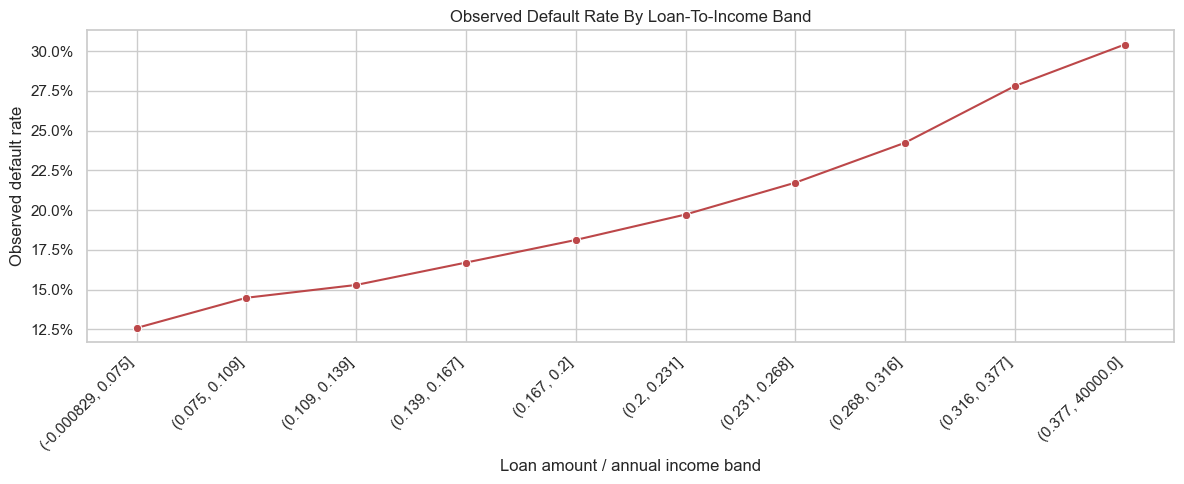

In [12]:
safe_numeric = [feature for feature in numeric_features if feature in df]
corr = df[safe_numeric + ['default']].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', square=True)
plt.title('Correlation Among Current Safe Numeric Features And Default')
plt.show()

affordability = df[['loan_amnt', 'annual_inc', 'default']].copy()
affordability = affordability[affordability['annual_inc'] > 0]
affordability['loan_to_income'] = affordability['loan_amnt'] / affordability['annual_inc']
affordability['band'] = pd.qcut(affordability['loan_to_income'], q=10, duplicates='drop')
affordability_profile = affordability.groupby('band', observed=False)['default'].agg(['count', 'mean']).reset_index()
affordability_profile['band'] = affordability_profile['band'].astype(str)
display(affordability_profile.rename(columns={'mean': 'default_rate'}))

plt.figure(figsize=(12, 5))
sns.lineplot(data=affordability_profile, x='band', y='mean', marker='o', color='#bc4749')
plt.gca().yaxis.set_major_formatter('{x:.1%}')
plt.xticks(rotation=45, ha='right')
plt.title('Observed Default Rate By Loan-To-Income Band')
plt.xlabel('Loan amount / annual income band')
plt.ylabel('Observed default rate')
plt.tight_layout()
plt.show()

## 11. EDA Conclusions And Modelling Actions

### Findings

- The final modelling cohort contains mature good/bad outcomes and has an approximately 20% default rate, so class imbalance must be handled with ranking and calibration metrics rather than accuracy alone.
- The raw dataset contains many post-origination fields. The existing ETL whitelist is therefore a necessary leakage control.
- Current model inputs are limited. Risk separation should be improved by auditing and adding valid application-time credit-profile features before changing to a more complex model family.
- Default-rate banding provides a direct check of whether each approved feature has useful risk signal and whether its relationship is plausibly monotonic.
- `int_rate` may carry pricing-policy information. Its availability must be aligned with the intended decision point before it is used in a production-like score.

### Actions Before Final Modelling

1. Audit the data dictionary and maintain an allowed/excluded feature inventory with timing rationale.
2. Preserve `issue_d` for an out-of-time train, validation, and test split.
3. Fit imputation, encoding, binning, feature selection, and calibration only on training data.
4. Add approved pre-origination credit-profile features and compare Logistic Regression + WoE, LightGBM, XGBoost, and CatBoost.
5. Select a final approval threshold using expected loss and profit trade-offs, not a fixed probability of 0.5.
